# M3 Multi-Item Association Rules — Olist E-commerce Recommendation

Ready-to-run notebook for Member 3.

This notebook starts from Member 2's PostgreSQL DWH views:
- `v_baskets_product`
- `v_baskets_category`
- `v_orders_with_holiday`

It produces Apriori, FP-Growth, ECLAT-style rules, sensitivity results, holiday/seasonal EDA, and ranked rules for M5.

## 1. Setup imports and project folders

In [1]:
import os
import time
from pathlib import Path
from getpass import getpass
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

from scipy.stats import chi2_contingency

print("Imports are working.")

Imports are working.


This cell finds the project root and creates output folders, even if the notebook is inside `notebooks/`.

In [2]:
# Detect project root robustly
cwd = Path.cwd()
project_root = cwd

for candidate in [cwd] + list(cwd.parents):
    if (candidate / "M2_DWH").exists() or (candidate / "olist_dwh.dump").exists():
        project_root = candidate
        break

os.chdir(project_root)

OUTPUT_RULES = Path("outputs/rules_multi_item")
OUTPUT_FIGURES = Path("outputs/figures_multi_item")
OUTPUT_RULES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

print("Current working directory:", Path.cwd())
print("Rules output folder:", OUTPUT_RULES.resolve())
print("Figures output folder:", OUTPUT_FIGURES.resolve())

Current working directory: d:\OneDrive\Desktop\Olist_DM_Phase2-20260514T203533Z-3-001\Olist_DM_Phase2
Rules output folder: D:\OneDrive\Desktop\Olist_DM_Phase2-20260514T203533Z-3-001\Olist_DM_Phase2\outputs\rules
Figures output folder: D:\OneDrive\Desktop\Olist_DM_Phase2-20260514T203533Z-3-001\Olist_DM_Phase2\outputs\figures


## 2. Connect to PostgreSQL DWH

In [3]:
password = os.environ.get("PGPASSWORD") or getpass("Enter PostgreSQL password for user postgres: ")

url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password=password,
    host="localhost",
    port=5432,
    database="olist_dwh"
)

engine = create_engine(url)

pd.read_sql("SELECT COUNT(*) AS n FROM v_baskets_category", engine)

,n
0,95146


Check that the three M3 views exist and return the expected row counts.

In [4]:
views_check = {
    "v_baskets_product": "SELECT COUNT(*) AS n FROM v_baskets_product",
    "v_baskets_category": "SELECT COUNT(*) AS n FROM v_baskets_category",
    "v_orders_with_holiday": "SELECT COUNT(*) AS n FROM v_orders_with_holiday"
}

for view_name, query in views_check.items():
    result = pd.read_sql(query, engine)
    print(view_name, "=", result["n"].iloc[0])

v_baskets_product = 96478
v_baskets_category = 95146
v_orders_with_holiday = 96478


## 3. Helper functions

In [5]:
def parse_pg_array(value):
    """
    Safely converts PostgreSQL array outputs into Python lists.
    Handles:
    - real Python lists/tuples/sets/np.ndarray
    - strings like "{a,b,c}"
    - nulls
    """
    if isinstance(value, (list, tuple, set, np.ndarray)):
        return list(value)

    if value is None:
        return []

    if pd.isna(value):
        return []

    value = str(value).strip()

    if value == "{}" or value == "":
        return []

    if value.startswith("{") and value.endswith("}"):
        value = value[1:-1]

    return [x.strip().strip('"') for x in value.split(",") if x.strip()]


def clean_transactions(transactions):
    """Remove empty baskets and duplicate items inside each basket."""
    return [
        list(set(t)) for t in transactions
        if t is not None and len(t) > 0
    ]


def basket_size_report(transactions, label):
    """Print basket size summary."""
    sizes = pd.Series([len(t) for t in transactions], name=f"{label}_basket_size")
    print(f"=== {label} basket sizes ===")
    print(sizes.describe())
    print("Single-item basket rate:", round((sizes == 1).mean() * 100, 2), "%")
    print("Multi-item baskets:", int((sizes >= 2).sum()))
    return sizes


def one_hot_encode(transactions, sparse=False):
    """Convert transaction lists to one-hot dataframe."""
    te = TransactionEncoder()
    arr = te.fit(transactions).transform(transactions, sparse=sparse)

    if sparse:
        onehot = pd.DataFrame.sparse.from_spmatrix(arr, columns=te.columns_)
    else:
        onehot = pd.DataFrame(arr, columns=te.columns_)

    return onehot


RULE_COLUMNS_FULL = [
    "antecedents", "consequents",
    "antecedent support", "consequent support",
    "support", "confidence", "lift",
    "representativity", "leverage", "conviction",
    "zhangs_metric", "jaccard", "certainty", "kulczynski"
]

RULE_COLUMNS_ECLAT = [
    "antecedents", "consequents",
    "antecedent support", "consequent support",
    "support", "confidence", "lift"
]


def save_rules(df, path, columns=None):
    """Save rules even if empty, with readable headers."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if df is None or len(df) == 0:
        if columns is None:
            columns = RULE_COLUMNS_FULL
        df = pd.DataFrame(columns=columns)

    df.to_csv(path, index=False)
    print(f"Saved: {path} | rows={len(df)}")


def sort_rules(rules_df):
    """Sort rules by quality."""
    if rules_df is None or len(rules_df) == 0:
        return rules_df

    sort_cols = [c for c in ["lift", "confidence", "support"] if c in rules_df.columns]
    return rules_df.sort_values(sort_cols, ascending=False)


def run_mlxtend_rules(onehot, algorithm_name, min_support=0.001, min_confidence=0.1, max_len=2):
    """Run Apriori or FP-Growth and generate association rules."""
    start = time.time()

    if algorithm_name.lower() == "apriori":
        freq = apriori(
            onehot,
            min_support=min_support,
            use_colnames=True,
            max_len=max_len
        )
    elif algorithm_name.lower() in ["fpgrowth", "fp-growth", "fp_growth"]:
        freq = fpgrowth(
            onehot,
            min_support=min_support,
            use_colnames=True,
            max_len=max_len
        )
    else:
        raise ValueError("algorithm_name must be 'apriori' or 'fpgrowth'")

    if len(freq) > 0 and (freq["itemsets"].apply(len) >= 2).any():
        rules = association_rules(
            freq,
            metric="confidence",
            min_threshold=min_confidence
        )
        rules = sort_rules(rules)
    else:
        rules = pd.DataFrame(columns=RULE_COLUMNS_FULL)

    runtime = time.time() - start

    print(f"=== {algorithm_name} ===")
    print("Frequent itemsets:", len(freq))
    print("Rules:", len(rules))
    print("Runtime seconds:", round(runtime, 2))

    return freq, rules, runtime


def eclat_pair_rules(transactions, min_support=0.001, min_confidence=0.1):
    """
    ECLAT-style pair rule mining using vertical transaction ID sets.
    This mines pair rules A -> B and B -> A.
    """
    start = time.time()
    n = len(transactions)

    item_tidsets = {}
    for tid, basket in enumerate(transactions):
        for item in basket:
            item_tidsets.setdefault(item, set()).add(tid)

    rows = []
    items = list(item_tidsets.keys())

    for a, b in combinations(items, 2):
        tids_a = item_tidsets[a]
        tids_b = item_tidsets[b]
        tids_ab = tids_a & tids_b

        support_ab = len(tids_ab) / n

        if support_ab >= min_support:
            support_a = len(tids_a) / n
            support_b = len(tids_b) / n

            # A -> B
            conf_a_to_b = support_ab / support_a if support_a > 0 else 0
            lift_a_to_b = conf_a_to_b / support_b if support_b > 0 else 0

            if conf_a_to_b >= min_confidence:
                rows.append({
                    "antecedents": frozenset([a]),
                    "consequents": frozenset([b]),
                    "antecedent support": support_a,
                    "consequent support": support_b,
                    "support": support_ab,
                    "confidence": conf_a_to_b,
                    "lift": lift_a_to_b
                })

            # B -> A
            conf_b_to_a = support_ab / support_b if support_b > 0 else 0
            lift_b_to_a = conf_b_to_a / support_a if support_a > 0 else 0

            if conf_b_to_a >= min_confidence:
                rows.append({
                    "antecedents": frozenset([b]),
                    "consequents": frozenset([a]),
                    "antecedent support": support_b,
                    "consequent support": support_a,
                    "support": support_ab,
                    "confidence": conf_b_to_a,
                    "lift": lift_b_to_a
                })

    rules = pd.DataFrame(rows, columns=RULE_COLUMNS_ECLAT)
    rules = sort_rules(rules)

    runtime = time.time() - start

    print("=== ECLAT-style pair rules ===")
    print("Rules:", len(rules))
    print("Runtime seconds:", round(runtime, 2))

    return rules, runtime


def itemset_to_string(x):
    """Convert frozenset/set/list/string to clean string for CSV/ranking."""
    if isinstance(x, str):
        return x
    if isinstance(x, (frozenset, set, list, tuple, np.ndarray)):
        return "|".join(sorted([str(i) for i in list(x)]))
    return str(x)


def make_ranked_rules(rules_df, algorithm, basket_type, condition="all", segment_id=None):
    """Convert association rules into ranked recommendation lists for M5 RRF."""
    if rules_df is None or len(rules_df) == 0:
        return pd.DataFrame(columns=[
            "query_item", "recommended_item", "rank",
            "algorithm", "basket_type", "condition", "segment_id",
            "support", "confidence", "lift"
        ])

    df = rules_df.copy()

    df["query_item"] = df["antecedents"].apply(itemset_to_string)
    df["recommended_item"] = df["consequents"].apply(itemset_to_string)
    df["algorithm"] = algorithm
    df["basket_type"] = basket_type
    df["condition"] = condition
    df["segment_id"] = segment_id

    df = df.sort_values(
        ["query_item", "lift", "confidence", "support"],
        ascending=[True, False, False, False]
    )

    df["rank"] = df.groupby("query_item").cumcount() + 1

    return df[
        [
            "query_item", "recommended_item", "rank",
            "algorithm", "basket_type", "condition", "segment_id",
            "support", "confidence", "lift"
        ]
    ]

## 4. Load M2 basket views

In [6]:
category_df = pd.read_sql("""
    SELECT order_id, category_groups
    FROM v_baskets_category
""", engine)

product_df = pd.read_sql("""
    SELECT order_id, products
    FROM v_baskets_product
""", engine)

holiday_df = pd.read_sql("""
    SELECT order_id, orderdate, is_holiday, holiday_name, season, is_weekend, payday_window
    FROM v_orders_with_holiday
""", engine)

category_df["category_groups"] = category_df["category_groups"].apply(parse_pg_array)
product_df["products"] = product_df["products"].apply(parse_pg_array)

print("category_df:", category_df.shape)
print("product_df:", product_df.shape)
print("holiday_df:", holiday_df.shape)

category_df.head(), product_df.head(), holiday_df.head()

# -------------------------------------------------------------------
# MULTI-ITEM EXPERIMENT FILTER
# Keep only orders with more than one DISTINCT product in the basket.
# This keeps the original database unchanged and filters only this experiment.
# -------------------------------------------------------------------
product_df["distinct_product_count"] = product_df["products"].apply(lambda xs: len(set(xs)) if isinstance(xs, list) else 0)
all_order_count = product_df["order_id"].nunique()
multi_item_order_ids = set(product_df.loc[product_df["distinct_product_count"] > 1, "order_id"])

category_df = category_df[category_df["order_id"].isin(multi_item_order_ids)].copy()
product_df = product_df[product_df["order_id"].isin(multi_item_order_ids)].copy()
holiday_df = holiday_df[holiday_df["order_id"].isin(multi_item_order_ids)].copy()

multi_summary = pd.DataFrame({
    "metric": [
        "all_orders_in_product_baskets",
        "multi_item_orders_distinct_product_gt_1",
        "removed_orders",
        "multi_item_percentage",
        "category_rows_after_filter",
        "product_rows_after_filter",
        "holiday_rows_after_filter"
    ],
    "value": [
        all_order_count,
        len(multi_item_order_ids),
        all_order_count - len(multi_item_order_ids),
        (len(multi_item_order_ids) / all_order_count * 100) if all_order_count else 0,
        len(category_df),
        len(product_df),
        len(holiday_df)
    ]
})
multi_summary.to_csv(OUTPUT_RULES / "multi_item_filter_summary_from_db.csv", index=False)

print("\n=== MULTI-ITEM FILTER APPLIED ===")
print(multi_summary.to_string(index=False))


category_df: (95146, 2)
product_df: (96478, 2)
holiday_df: (96478, 7)


(                           order_id      category_groups
 0  00010242fe8c5a6d1ba2dd792cb16214   [electronics_misc]
 1  00018f77f2f0320c557190d7a144bdd3  [diversified_other]
 2  000229ec398224ef6ca0657da4fc703e   [moveis_decoracao]
 3  00024acbcdf0a6daa1e931b038114c75  [diversified_other]
 4  00042b26cf59d7ce69dfabb4e55b4fd9    [gifts_household],
                            order_id                            products
 0  00010242fe8c5a6d1ba2dd792cb16214  [4244733e06e7ecb4970a6e2683c13e61]
 1  00018f77f2f0320c557190d7a144bdd3  [e5f2d52b802189ee658865ca93d83a8f]
 2  000229ec398224ef6ca0657da4fc703e  [c777355d18b72b67abbeef9df44fd0fd]
 3  00024acbcdf0a6daa1e931b038114c75  [7634da152a4610f1595efa32f14722fc]
 4  00042b26cf59d7ce69dfabb4e55b4fd9  [ac6c3623068f30de03045865e4e10089],
                            order_id   orderdate  is_holiday holiday_name  \
 0  00010242fe8c5a6d1ba2dd792cb16214  2017-09-13       False          NaN   
 1  00018f77f2f0320c557190d7a144bdd3  2017-04-26       Fal

## 5. Basket-size EDA

In [7]:
category_transactions = clean_transactions(category_df["category_groups"].tolist())
product_transactions = clean_transactions(product_df["products"].tolist())

category_basket_sizes = basket_size_report(category_transactions, "category")
print()
product_basket_sizes = basket_size_report(product_transactions, "product")

=== category basket sizes ===
count    95146.000000
mean         1.004519
std          0.068163
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: category_basket_size, dtype: float64
Single-item basket rate: 99.56 %
Multi-item baskets: 423

=== product basket sizes ===
count    96478.000000
mean         1.038537
std          0.227942
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: product_basket_size, dtype: float64
Single-item basket rate: 96.69 %
Multi-item baskets: 3197


Save basket-size summaries for the paper.

In [8]:
basket_summary = pd.DataFrame({
    "metric": ["count", "mean", "std", "min", "25%", "50%", "75%", "max", "single_item_rate", "multi_item_count"],
    "category_baskets": [
        category_basket_sizes.count(),
        category_basket_sizes.mean(),
        category_basket_sizes.std(),
        category_basket_sizes.min(),
        category_basket_sizes.quantile(0.25),
        category_basket_sizes.quantile(0.50),
        category_basket_sizes.quantile(0.75),
        category_basket_sizes.max(),
        (category_basket_sizes == 1).mean(),
        (category_basket_sizes >= 2).sum()
    ],
    "product_baskets": [
        product_basket_sizes.count(),
        product_basket_sizes.mean(),
        product_basket_sizes.std(),
        product_basket_sizes.min(),
        product_basket_sizes.quantile(0.25),
        product_basket_sizes.quantile(0.50),
        product_basket_sizes.quantile(0.75),
        product_basket_sizes.max(),
        (product_basket_sizes == 1).mean(),
        (product_basket_sizes >= 2).sum()
    ]
})

basket_summary.to_csv(OUTPUT_RULES / "basket_size_summary.csv", index=False)
basket_summary

,metric,category_baskets,product_baskets
0,count,95146.000000,96478.000000
1,mean,1.004519,1.038537
2,std,0.068163,0.227942
3,min,1.000000,1.000000
4,25%,1.000000,1.000000
5,50%,1.000000,1.000000
6,75%,1.000000,1.000000
7,max,3.000000,8.000000
8,single_item_rate,0.995554,0.966863
9,multi_item_count,423.000000,3197.000000


## 6. Category-level mining

In [9]:
category_onehot = one_hot_encode(category_transactions, sparse=False)

print("Category one-hot shape:", category_onehot.shape)
category_onehot.head()

Category one-hot shape: (95146, 10)


,cama_mesa_banho,construcao_ferramentas_jardim,diversified_other,electronics_misc,fashion_apparel,fashion_bolsas_e_acessorios,gifts_household,livros_tecnicos,moveis_decoracao,music_homecomfort
0,False,False,False,True,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False
3,False,False,True,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False


Run Apriori on category-group baskets.

In [10]:
CAT_MIN_SUPPORT = 0.0001
CAT_MIN_CONFIDENCE = 0.05

freq_cat_apriori, rules_cat_apriori, runtime_cat_apriori = run_mlxtend_rules(
    category_onehot,
    algorithm_name="apriori",
    min_support=CAT_MIN_SUPPORT,
    min_confidence=CAT_MIN_CONFIDENCE,
    max_len=2
)

display(rules_cat_apriori.head(20))
save_rules(rules_cat_apriori, OUTPUT_RULES / "category_apriori_rules.csv", RULE_COLUMNS_FULL)

=== apriori ===
Frequent itemsets: 19
Rules: 0
Runtime seconds: 0.02


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


Saved: outputs\rules\category_apriori_rules.csv | rows=0


Run FP-Growth on category-group baskets.

In [11]:
freq_cat_fpgrowth, rules_cat_fpgrowth, runtime_cat_fpgrowth = run_mlxtend_rules(
    category_onehot,
    algorithm_name="fpgrowth",
    min_support=CAT_MIN_SUPPORT,
    min_confidence=CAT_MIN_CONFIDENCE,
    max_len=2
)

display(rules_cat_fpgrowth.head(20))
save_rules(rules_cat_fpgrowth, OUTPUT_RULES / "category_fpgrowth_rules.csv", RULE_COLUMNS_FULL)

=== fpgrowth ===
Frequent itemsets: 19
Rules: 0
Runtime seconds: 0.24


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


Saved: outputs\rules\category_fpgrowth_rules.csv | rows=0


Run ECLAT-style pair mining on category-group baskets.

In [12]:
rules_cat_eclat, runtime_cat_eclat = eclat_pair_rules(
    category_transactions,
    min_support=CAT_MIN_SUPPORT,
    min_confidence=CAT_MIN_CONFIDENCE
)

display(rules_cat_eclat.head(20))
save_rules(rules_cat_eclat, OUTPUT_RULES / "category_eclat_rules.csv", RULE_COLUMNS_ECLAT)

=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.06


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift


Saved: outputs\rules\category_eclat_rules.csv | rows=0


## 7. Product-level mining with threshold trials

In [13]:
# Filter to reasonably frequent products to avoid a huge one-hot matrix
# You can lower this if you need more rules, but it may use more memory/time.
MIN_PRODUCT_COUNT = 50

product_counts = pd.Series([item for basket in product_transactions for item in basket]).value_counts()
frequent_products = set(product_counts[product_counts >= MIN_PRODUCT_COUNT].index)

filtered_product_transactions = []
for basket in product_transactions:
    filtered = [item for item in basket if item in frequent_products]
    if len(filtered) > 0:
        filtered_product_transactions.append(list(set(filtered)))

filtered_product_basket_sizes = basket_size_report(filtered_product_transactions, "filtered product")

print("Original unique products:", product_counts.shape[0])
print("Filtered products count:", len(frequent_products))
print("Filtered transactions:", len(filtered_product_transactions))

=== filtered product basket sizes ===
count    15039.00000
mean         1.01270
std          0.11777
min          1.00000
25%          1.00000
50%          1.00000
75%          1.00000
max          4.00000
Name: filtered product_basket_size, dtype: float64
Single-item basket rate: 98.79 %
Multi-item baskets: 182
Original unique products: 32216
Filtered products count: 145
Filtered transactions: 15039


In [14]:
product_onehot = one_hot_encode(filtered_product_transactions, sparse=True)

print("Product one-hot shape:", product_onehot.shape)
product_onehot.head()

Product one-hot shape: (15039, 145)


,0152f69b6cf919bcdaf117aa8c43e5a2,06c6e01186af8b98ee1fc9e01f9471e9,06edb72f1e0c64b14c5b79353f7abea3,08574b074924071f4e201e151b152b4e,0a57f7d2c983bcf8188589a5fea4a8da,0aabfb375647d9738ad0f7b4ea3653b1,0bcc3eeca39e1064258aa1e932269894,0d85c435fd60b277ffb9e9b0f88f927a,11875b30b49585209e608f40e8082e65,154e7e31ebfa092203795c972e5804a6,...,f264c1d9b20b5e4a340254d0405e613b,f35927953ed82e19d06ad3aac2f06353,f4f67ccaece962d013a4e1d7dc3a61f7,f71973c922ccaab05514a36a8bc741b8,f71f42e2381752836563b70beb542f80,f7a17d2c51d9df89a4f1711c4ac17f33,fb55982be901439613a95940feefd9ee,fbc1488c1a1e72ba175f53ab29a248e8,fbce4c4cb307679d89a3bf3d3bb353b9,fc1d8637c0268af3db482c14b7ef8e75
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Try several product support/confidence thresholds before choosing the final one.

In [15]:
support_trials = [0.001, 0.0008, 0.0005, 0.0003, 0.0002]
confidence_trials = [0.05, 0.08, 0.10]

trial_rows = []

for min_sup in support_trials:
    for min_conf in confidence_trials:
        start = time.time()

        freq = fpgrowth(
            product_onehot,
            min_support=min_sup,
            use_colnames=True,
            max_len=2
        )

        if len(freq) > 0 and (freq["itemsets"].apply(len) >= 2).any():
            rules = association_rules(freq, metric="confidence", min_threshold=min_conf)
        else:
            rules = pd.DataFrame(columns=RULE_COLUMNS_FULL)

        runtime = time.time() - start

        trial_rows.append({
            "min_support": min_sup,
            "min_confidence": min_conf,
            "frequent_itemsets": len(freq),
            "rules": len(rules),
            "average_lift": rules["lift"].mean() if len(rules) > 0 else 0,
            "runtime_seconds": runtime
        })

product_threshold_trials = pd.DataFrame(trial_rows)
product_threshold_trials.to_csv(OUTPUT_RULES / "product_threshold_trials.csv", index=False)

product_threshold_trials.sort_values(["rules", "average_lift"], ascending=False)

,min_support,min_confidence,frequent_itemsets,rules,average_lift,runtime_seconds
9,0.0003,0.05,156,10,22.593452,0.039385
12,0.0002,0.05,157,10,22.593452,0.042359
6,0.0005,0.05,152,8,27.191503,0.035646
7,0.0005,0.08,152,7,30.182980,0.035908
8,0.0005,0.10,152,7,30.182980,0.040315
10,0.0003,0.08,156,7,30.182980,0.036195
11,0.0003,0.10,156,7,30.182980,0.044549
13,0.0002,0.08,157,7,30.182980,0.042347
14,0.0002,0.10,157,7,30.182980,0.046362
0,0.0010,0.05,148,6,29.244148,0.053636


Choose the best product threshold automatically. You can override it manually after seeing the table above.

In [16]:
# Automatic choice:
# Prefer settings with at least some rules but not too many.
candidates = product_threshold_trials[
    (product_threshold_trials["rules"] > 0) &
    (product_threshold_trials["rules"] <= 300)
].copy()

if len(candidates) > 0:
    selected = candidates.sort_values(["rules", "average_lift"], ascending=[False, False]).iloc[0]
else:
    selected = product_threshold_trials.sort_values(["rules", "average_lift"], ascending=[False, False]).iloc[0]

PROD_MIN_SUPPORT = float(selected["min_support"])
PROD_MIN_CONFIDENCE = float(selected["min_confidence"])

print("Selected product min_support:", PROD_MIN_SUPPORT)
print("Selected product min_confidence:", PROD_MIN_CONFIDENCE)
print(selected)

Selected product min_support: 0.0003
Selected product min_confidence: 0.05
min_support            0.000300
min_confidence         0.050000
frequent_itemsets    156.000000
rules                 10.000000
average_lift          22.593452
runtime_seconds        0.039385
Name: 9, dtype: float64


Run final Apriori, FP-Growth, and ECLAT-style product-level rules using the selected threshold.

In [17]:
freq_prod_apriori, rules_prod_apriori, runtime_prod_apriori = run_mlxtend_rules(
    product_onehot,
    algorithm_name="apriori",
    min_support=PROD_MIN_SUPPORT,
    min_confidence=PROD_MIN_CONFIDENCE,
    max_len=2
)

display(rules_prod_apriori.head(30))
save_rules(rules_prod_apriori, OUTPUT_RULES / "product_apriori_rules.csv", RULE_COLUMNS_FULL)

=== apriori ===
Frequent itemsets: 156
Rules: 10
Runtime seconds: 0.84


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
8,frozenset({f4f67ccaece962d013a4e1d7dc3a61f7}),frozenset({4fcb3d9a5f4871e8362dfedbdb02b064}),0.003724,0.005918,0.001130,0.303571,51.296750,1.0,0.001108,1.427400,0.984170,0.132812,0.299425,0.247291
9,frozenset({4fcb3d9a5f4871e8362dfedbdb02b064}),frozenset({f4f67ccaece962d013a4e1d7dc3a61f7}),0.005918,0.003724,0.001130,0.191011,51.296750,1.0,0.001108,1.231508,0.986343,0.132812,0.187988,0.247291
6,frozenset({e53e557d5a159f5aa2c5e995dfdf244b}),frozenset({36f60d45225e60c7da4558b070ce4b60}),0.010240,0.007314,0.002261,0.220779,30.184534,1.0,0.002186,1.273947,0.976874,0.147826,0.215038,0.264935
7,frozenset({36f60d45225e60c7da4558b070ce4b60}),frozenset({e53e557d5a159f5aa2c5e995dfdf244b}),0.007314,0.010240,0.002261,0.309091,30.184534,1.0,0.002186,1.432547,0.973995,0.147826,0.301943,0.264935
4,frozenset({3f14d740544f37ece8a9e7bc8349797e}),frozenset({36f60d45225e60c7da4558b070ce4b60}),0.005187,0.007314,0.000798,0.153846,21.033566,1.0,0.000760,1.173174,0.957423,0.068182,0.147612,0.131469
5,frozenset({36f60d45225e60c7da4558b070ce4b60}),frozenset({3f14d740544f37ece8a9e7bc8349797e}),0.007314,0.005187,0.000798,0.109091,21.033566,1.0,0.000760,1.116627,0.959475,0.068182,0.104446,0.131469
3,frozenset({99a4788cb24856965c36a24e339b6058}),frozenset({35afc973633aaeb6b877ff57b2793310}),0.030321,0.010174,0.001928,0.063596,6.251161,1.0,0.001620,1.057051,0.866297,0.050000,0.053972,0.126569
2,frozenset({35afc973633aaeb6b877ff57b2793310}),frozenset({99a4788cb24856965c36a24e339b6058}),0.010174,0.030321,0.001928,0.189542,6.251161,1.0,0.001620,1.196459,0.848664,0.050000,0.164200,0.126569
0,frozenset({6c3effec7c8ddba466d4f03f982c7aa3}),frozenset({0aabfb375647d9738ad0f7b4ea3653b1}),0.006250,0.009110,0.000332,0.053191,5.839028,1.0,0.000276,1.046558,0.833951,0.022124,0.044487,0.044844
1,frozenset({0bcc3eeca39e1064258aa1e932269894}),frozenset({422879e10f46682990de24d770e7f83d}),0.006649,0.023406,0.000399,0.060000,2.563466,1.0,0.000243,1.038930,0.613986,0.013453,0.037471,0.038523


Saved: outputs\rules\product_apriori_rules.csv | rows=10


In [18]:
freq_prod_fpgrowth, rules_prod_fpgrowth, runtime_prod_fpgrowth = run_mlxtend_rules(
    product_onehot,
    algorithm_name="fpgrowth",
    min_support=PROD_MIN_SUPPORT,
    min_confidence=PROD_MIN_CONFIDENCE,
    max_len=2
)

display(rules_prod_fpgrowth.head(30))
save_rules(rules_prod_fpgrowth, OUTPUT_RULES / "product_fpgrowth_rules.csv", RULE_COLUMNS_FULL)

=== fpgrowth ===
Frequent itemsets: 156
Rules: 10
Runtime seconds: 0.05


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
8,frozenset({f4f67ccaece962d013a4e1d7dc3a61f7}),frozenset({4fcb3d9a5f4871e8362dfedbdb02b064}),0.003724,0.005918,0.001130,0.303571,51.296750,1.0,0.001108,1.427400,0.984170,0.132812,0.299425,0.247291
9,frozenset({4fcb3d9a5f4871e8362dfedbdb02b064}),frozenset({f4f67ccaece962d013a4e1d7dc3a61f7}),0.005918,0.003724,0.001130,0.191011,51.296750,1.0,0.001108,1.231508,0.986343,0.132812,0.187988,0.247291
6,frozenset({e53e557d5a159f5aa2c5e995dfdf244b}),frozenset({36f60d45225e60c7da4558b070ce4b60}),0.010240,0.007314,0.002261,0.220779,30.184534,1.0,0.002186,1.273947,0.976874,0.147826,0.215038,0.264935
7,frozenset({36f60d45225e60c7da4558b070ce4b60}),frozenset({e53e557d5a159f5aa2c5e995dfdf244b}),0.007314,0.010240,0.002261,0.309091,30.184534,1.0,0.002186,1.432547,0.973995,0.147826,0.301943,0.264935
0,frozenset({3f14d740544f37ece8a9e7bc8349797e}),frozenset({36f60d45225e60c7da4558b070ce4b60}),0.005187,0.007314,0.000798,0.153846,21.033566,1.0,0.000760,1.173174,0.957423,0.068182,0.147612,0.131469
1,frozenset({36f60d45225e60c7da4558b070ce4b60}),frozenset({3f14d740544f37ece8a9e7bc8349797e}),0.007314,0.005187,0.000798,0.109091,21.033566,1.0,0.000760,1.116627,0.959475,0.068182,0.104446,0.131469
3,frozenset({99a4788cb24856965c36a24e339b6058}),frozenset({35afc973633aaeb6b877ff57b2793310}),0.030321,0.010174,0.001928,0.063596,6.251161,1.0,0.001620,1.057051,0.866297,0.050000,0.053972,0.126569
2,frozenset({35afc973633aaeb6b877ff57b2793310}),frozenset({99a4788cb24856965c36a24e339b6058}),0.010174,0.030321,0.001928,0.189542,6.251161,1.0,0.001620,1.196459,0.848664,0.050000,0.164200,0.126569
5,frozenset({6c3effec7c8ddba466d4f03f982c7aa3}),frozenset({0aabfb375647d9738ad0f7b4ea3653b1}),0.006250,0.009110,0.000332,0.053191,5.839028,1.0,0.000276,1.046558,0.833951,0.022124,0.044487,0.044844
4,frozenset({0bcc3eeca39e1064258aa1e932269894}),frozenset({422879e10f46682990de24d770e7f83d}),0.006649,0.023406,0.000399,0.060000,2.563466,1.0,0.000243,1.038930,0.613986,0.013453,0.037471,0.038523


Saved: outputs\rules\product_fpgrowth_rules.csv | rows=10


In [19]:
rules_prod_eclat, runtime_prod_eclat = eclat_pair_rules(
    filtered_product_transactions,
    min_support=PROD_MIN_SUPPORT,
    min_confidence=PROD_MIN_CONFIDENCE
)

display(rules_prod_eclat.head(30))
save_rules(rules_prod_eclat, OUTPUT_RULES / "product_eclat_rules.csv", RULE_COLUMNS_ECLAT)

=== ECLAT-style pair rules ===
Rules: 10
Runtime seconds: 0.04


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
8,frozenset({f4f67ccaece962d013a4e1d7dc3a61f7}),frozenset({4fcb3d9a5f4871e8362dfedbdb02b064}),0.003724,0.005918,0.001130,0.303571,51.296750
9,frozenset({4fcb3d9a5f4871e8362dfedbdb02b064}),frozenset({f4f67ccaece962d013a4e1d7dc3a61f7}),0.005918,0.003724,0.001130,0.191011,51.296750
4,frozenset({e53e557d5a159f5aa2c5e995dfdf244b}),frozenset({36f60d45225e60c7da4558b070ce4b60}),0.010240,0.007314,0.002261,0.220779,30.184534
5,frozenset({36f60d45225e60c7da4558b070ce4b60}),frozenset({e53e557d5a159f5aa2c5e995dfdf244b}),0.007314,0.010240,0.002261,0.309091,30.184534
2,frozenset({3f14d740544f37ece8a9e7bc8349797e}),frozenset({36f60d45225e60c7da4558b070ce4b60}),0.005187,0.007314,0.000798,0.153846,21.033566
3,frozenset({36f60d45225e60c7da4558b070ce4b60}),frozenset({3f14d740544f37ece8a9e7bc8349797e}),0.007314,0.005187,0.000798,0.109091,21.033566
0,frozenset({99a4788cb24856965c36a24e339b6058}),frozenset({35afc973633aaeb6b877ff57b2793310}),0.030321,0.010174,0.001928,0.063596,6.251161
1,frozenset({35afc973633aaeb6b877ff57b2793310}),frozenset({99a4788cb24856965c36a24e339b6058}),0.010174,0.030321,0.001928,0.189542,6.251161
6,frozenset({6c3effec7c8ddba466d4f03f982c7aa3}),frozenset({0aabfb375647d9738ad0f7b4ea3653b1}),0.006250,0.009110,0.000332,0.053191,5.839028
7,frozenset({0bcc3eeca39e1064258aa1e932269894}),frozenset({422879e10f46682990de24d770e7f83d}),0.006649,0.023406,0.000399,0.060000,2.563466


Saved: outputs\rules\product_eclat_rules.csv | rows=10


## 8. Category sensitivity sweep

In [20]:
supports = [0.001, 0.005, 0.01, 0.02, 0.0005, 0.0001]
confidences = [0.1, 0.3, 0.5, 0.7, 0.05]

sweep_rows = []

for alg in ["apriori", "fpgrowth"]:
    for min_sup in supports:
        for min_conf in confidences:
            start = time.time()

            if alg == "apriori":
                freq = apriori(category_onehot, min_support=min_sup, use_colnames=True, max_len=2)
            else:
                freq = fpgrowth(category_onehot, min_support=min_sup, use_colnames=True, max_len=2)

            if len(freq) > 0 and (freq["itemsets"].apply(len) >= 2).any():
                rules = association_rules(freq, metric="confidence", min_threshold=min_conf)
            else:
                rules = pd.DataFrame(columns=RULE_COLUMNS_FULL)

            runtime = time.time() - start

            sweep_rows.append({
                "algorithm": "Apriori" if alg == "apriori" else "FP-Growth",
                "basket_type": "category",
                "min_support": min_sup,
                "min_confidence": min_conf,
                "number_of_rules": len(rules),
                "average_lift": rules["lift"].mean() if len(rules) > 0 else 0,
                "runtime_seconds": runtime
            })

# ECLAT-style category sensitivity
for min_sup in supports:
    for min_conf in confidences:
        start = time.time()
        rules, _ = eclat_pair_rules(category_transactions, min_support=min_sup, min_confidence=min_conf)
        runtime = time.time() - start

        sweep_rows.append({
            "algorithm": "ECLAT-style",
            "basket_type": "category",
            "min_support": min_sup,
            "min_confidence": min_conf,
            "number_of_rules": len(rules),
            "average_lift": rules["lift"].mean() if len(rules) > 0 else 0,
            "runtime_seconds": runtime
        })

sensitivity_df = pd.DataFrame(sweep_rows)
sensitivity_df.to_csv(OUTPUT_RULES / "sensitivity_results_category.csv", index=False)

sensitivity_df.head(20)

=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.02
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.03
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.03
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.03
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.03
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.03
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.03
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.03
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.03
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.02
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.03
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.03
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.03
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.03
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.03
=== ECLAT-style pair rules ===
Rules: 0
Runtime seconds: 0.03
=== ECLA

,algorithm,basket_type,min_support,min_confidence,number_of_rules,average_lift,runtime_seconds
0,Apriori,category,0.001,0.10,0,0,0.013523
1,Apriori,category,0.001,0.30,0,0,0.012642
2,Apriori,category,0.001,0.50,0,0,0.010193
3,Apriori,category,0.001,0.70,0,0,0.011427
4,Apriori,category,0.001,0.05,0,0,0.010499
5,Apriori,category,0.005,0.10,0,0,0.007406
6,Apriori,category,0.005,0.30,0,0,0.007266
7,Apriori,category,0.005,0.50,0,0,0.006496
8,Apriori,category,0.005,0.70,0,0,0.006188
9,Apriori,category,0.005,0.05,0,0,0.007056


Plot rule count and average lift for the category sensitivity sweep.

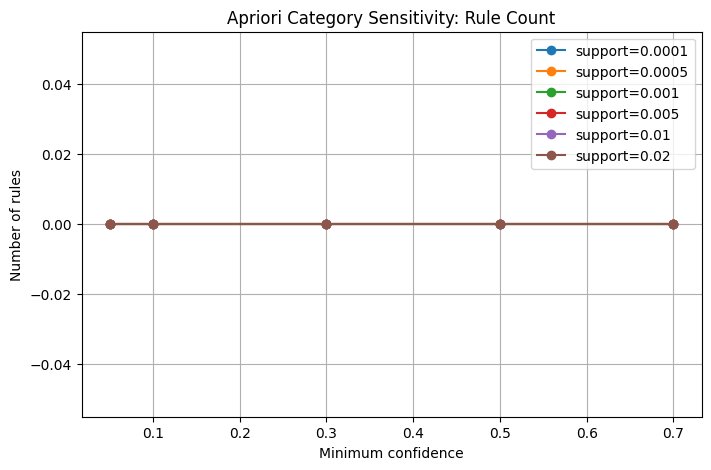

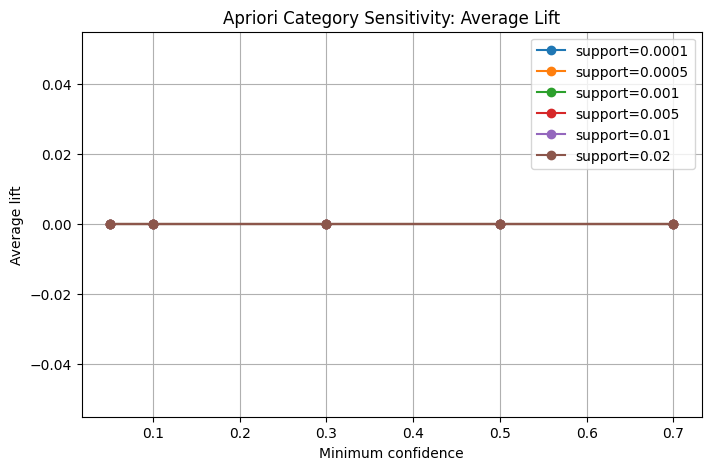

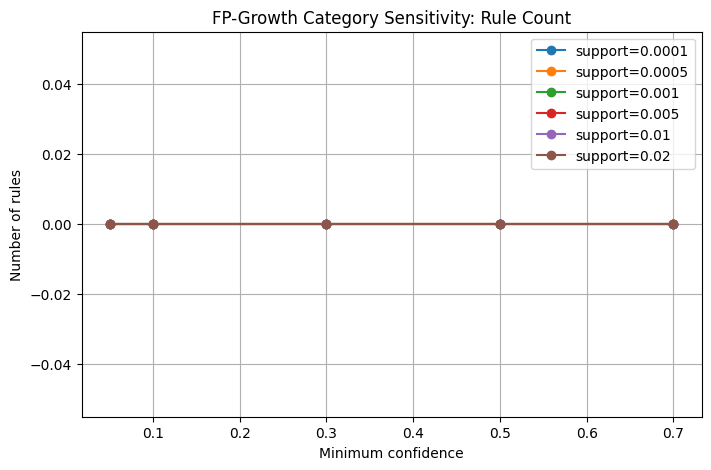

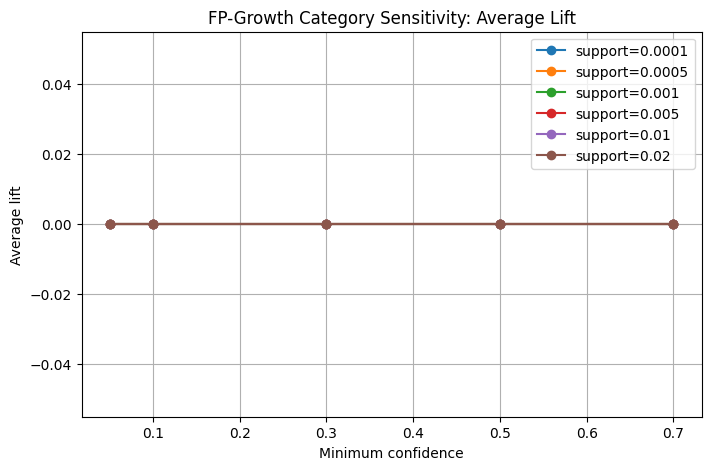

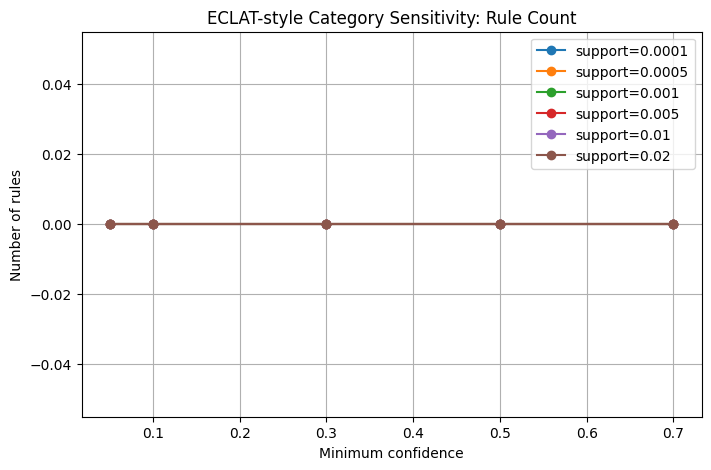

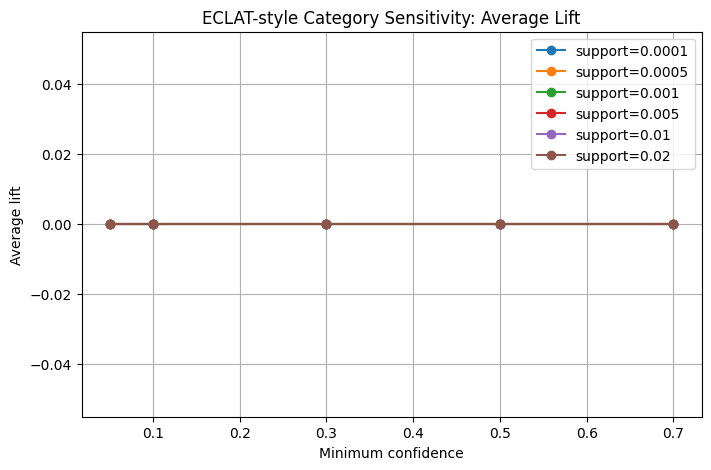

Saved sensitivity figures to: D:\OneDrive\Desktop\Olist_DM_Phase2-20260514T203533Z-3-001\Olist_DM_Phase2\outputs\figures


In [21]:
for alg_name in sensitivity_df["algorithm"].unique():
    temp_alg = sensitivity_df[sensitivity_df["algorithm"] == alg_name]

    plt.figure(figsize=(8, 5))
    for min_sup in sorted(temp_alg["min_support"].unique()):
        temp = temp_alg[temp_alg["min_support"] == min_sup].sort_values("min_confidence")
        plt.plot(temp["min_confidence"], temp["number_of_rules"], marker="o", label=f"support={min_sup}")

    plt.xlabel("Minimum confidence")
    plt.ylabel("Number of rules")
    plt.title(f"{alg_name} Category Sensitivity: Rule Count")
    plt.legend()
    plt.grid(True)
    filename = f"category_{alg_name.lower().replace('-', '_').replace(' ', '_')}_rule_count_sweep.png"
    plt.savefig(OUTPUT_FIGURES / filename, dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    for min_sup in sorted(temp_alg["min_support"].unique()):
        temp = temp_alg[temp_alg["min_support"] == min_sup].sort_values("min_confidence")
        plt.plot(temp["min_confidence"], temp["average_lift"], marker="o", label=f"support={min_sup}")

    plt.xlabel("Minimum confidence")
    plt.ylabel("Average lift")
    plt.title(f"{alg_name} Category Sensitivity: Average Lift")
    plt.legend()
    plt.grid(True)
    filename = f"category_{alg_name.lower().replace('-', '_').replace(' ', '_')}_avg_lift_sweep.png"
    plt.savefig(OUTPUT_FIGURES / filename, dpi=300, bbox_inches="tight")
    plt.show()

print("Saved sensitivity figures to:", OUTPUT_FIGURES.resolve())

## 9. Holiday EDA and seasonal decision

In [22]:
cat_holiday = category_df.merge(holiday_df, on="order_id", how="inner")
cat_holiday["basket_size"] = cat_holiday["category_groups"].apply(len)

holiday_counts = cat_holiday["is_holiday"].value_counts(dropna=False)
print("Holiday basket counts:")
print(holiday_counts)

print("\nBasket size by holiday flag:")
display(cat_holiday.groupby("is_holiday")["basket_size"].describe())

holiday_baskets = int(cat_holiday["is_holiday"].sum())
nonholiday_baskets = int((~cat_holiday["is_holiday"]).sum())

# Category mix table
cat_exploded = cat_holiday[["order_id", "is_holiday", "category_groups"]].explode("category_groups")
category_mix = (
    cat_exploded.groupby(["is_holiday", "category_groups"])
    .size()
    .reset_index(name="count")
)

category_mix["proportion"] = category_mix.groupby("is_holiday")["count"].transform(lambda x: x / x.sum())
category_mix = category_mix.rename(columns={"category_groups": "category_group"})

category_mix.to_csv(OUTPUT_RULES / "holiday_category_mix.csv", index=False)

# Chi-square test if possible
pivot_mix = category_mix.pivot_table(
    index="is_holiday",
    columns="category_group",
    values="count",
    fill_value=0
)

if pivot_mix.shape[0] == 2 and pivot_mix.shape[1] > 1:
    chi2, p_value, dof, expected = chi2_contingency(pivot_mix)
else:
    chi2, p_value, dof = np.nan, np.nan, np.nan

decision = "holiday" if (holiday_baskets >= 5000 and p_value < 0.05) else "seasonal"

holiday_eda_summary = pd.DataFrame({
    "metric": [
        "holiday_baskets",
        "nonholiday_baskets",
        "chi_square_p_value",
        "decision"
    ],
    "value": [
        holiday_baskets,
        nonholiday_baskets,
        p_value,
        decision
    ]
})

holiday_eda_summary.to_csv(OUTPUT_RULES / "holiday_eda_summary.csv", index=False)

print("\nHoliday baskets:", holiday_baskets)
print("Non-holiday baskets:", nonholiday_baskets)
print("Chi-square p-value:", p_value)
print("Decision:", decision)

display(holiday_eda_summary)
display(category_mix.head(20))

Holiday basket counts:
is_holiday
False    93687
True      1459
Name: count, dtype: int64

Basket size by holiday flag:


,count,mean,std,min,25%,50%,75%,max
is_holiday,,,,,,,,
False,93687.0,1.004472,0.067837,1.0,1.0,1.0,1.0,3.0
True,1459.0,1.007539,0.086531,1.0,1.0,1.0,1.0,2.0



Holiday baskets: 1459
Non-holiday baskets: 93687
Chi-square p-value: 0.08176140012376523
Decision: seasonal


,metric,value
0,holiday_baskets,1459
1,nonholiday_baskets,93687
2,chi_square_p_value,0.081761
3,decision,seasonal


,is_holiday,category_group,count,proportion
0,False,cama_mesa_banho,9465,0.100578
1,False,construcao_ferramentas_jardim,215,0.002285
2,False,diversified_other,60968,0.647865
3,False,electronics_misc,3571,0.037947
4,False,fashion_apparel,59,0.000627
5,False,fashion_bolsas_e_acessorios,1794,0.019064
6,False,gifts_household,9898,0.105179
7,False,livros_tecnicos,289,0.003071
8,False,moveis_decoracao,7222,0.076743
9,False,music_homecomfort,625,0.006641


Mine condition-based rules. If holiday data is weak, the notebook uses seasonal mining.

In [23]:
condition_rule_tables = []

if decision == "holiday":
    print("Mining holiday vs non-holiday category rules.")

    for flag in [False, True]:
        condition_name = "holiday" if flag else "non_holiday"
        tx = cat_holiday.loc[cat_holiday["is_holiday"] == flag, "category_groups"].tolist()
        tx = clean_transactions(tx)

        if len(tx) < 100:
            continue

        onehot = one_hot_encode(tx, sparse=False)
        _, rules, runtime = run_mlxtend_rules(
            onehot,
            algorithm_name="fpgrowth",
            min_support=CAT_MIN_SUPPORT,
            min_confidence=CAT_MIN_CONFIDENCE,
            max_len=2
        )

        rules["condition"] = condition_name
        rules["algorithm"] = "FP-Growth"
        rules["basket_type"] = "category"
        condition_rule_tables.append(rules)

else:
    print("Holiday signal is weak, so mining seasonal category rules instead.")

    for season_name in sorted(cat_holiday["season"].dropna().unique()):
        tx = cat_holiday.loc[cat_holiday["season"] == season_name, "category_groups"].tolist()
        tx = clean_transactions(tx)

        if len(tx) < 100:
            continue

        onehot = one_hot_encode(tx, sparse=False)
        _, rules, runtime = run_mlxtend_rules(
            onehot,
            algorithm_name="fpgrowth",
            min_support=CAT_MIN_SUPPORT,
            min_confidence=CAT_MIN_CONFIDENCE,
            max_len=2
        )

        rules["condition"] = season_name
        rules["algorithm"] = "FP-Growth"
        rules["basket_type"] = "category"
        condition_rule_tables.append(rules)

        print(f"Season={season_name} | baskets={len(tx)} | rules={len(rules)} | runtime={round(runtime, 2)}s")

if len(condition_rule_tables) > 0:
    conditional_rules = pd.concat(condition_rule_tables, ignore_index=True)
    conditional_rules = sort_rules(conditional_rules)
else:
    conditional_rules = pd.DataFrame(columns=RULE_COLUMNS_FULL + ["condition", "algorithm", "basket_type"])

save_rules(conditional_rules, OUTPUT_RULES / "seasonal_category_rules.csv", list(conditional_rules.columns))
display(conditional_rules.head(20))

Holiday signal is weak, so mining seasonal category rules instead.
=== fpgrowth ===
Frequent itemsets: 19
Rules: 0
Runtime seconds: 0.09
Season=Inverno | baskets=29561 | rules=0 | runtime=0.09s
=== fpgrowth ===
Frequent itemsets: 21
Rules: 0
Runtime seconds: 0.06
Season=Outono | baskets=28537 | rules=0 | runtime=0.06s
=== fpgrowth ===
Frequent itemsets: 19
Rules: 0
Runtime seconds: 0.04
Season=Primavera | baskets=15970 | rules=0 | runtime=0.04s
=== fpgrowth ===
Frequent itemsets: 18
Rules: 0
Runtime seconds: 0.05
Season=Verão | baskets=21078 | rules=0 | runtime=0.05s
Saved: outputs\rules\seasonal_category_rules.csv | rows=0


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,condition,algorithm,basket_type


## 10. Optional: inspect product dimension columns for readable product info

In [24]:
dim_product_columns = pd.read_sql("""
SELECT column_name
FROM information_schema.columns
WHERE table_name = 'dim_products'
ORDER BY ordinal_position
""", engine)

dim_product_columns

,column_name
0,product_id
1,product_category_name
2,product_category_name_english
3,product_weight_g
4,product_length_cm
5,product_height_cm
6,product_width_cm
7,product_photos_qty
8,category_group_id


This optional cell tries to load a product lookup table. It will not break the notebook if column names are different.

In [25]:
try:
    dim_products_preview = pd.read_sql("SELECT * FROM dim_products LIMIT 5", engine)
    display(dim_products_preview)
except Exception as e:
    print("Could not preview dim_products:", e)

,product_id,product_category_name,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_photos_qty,category_group_id
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,225,16,10,14,1,10
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,1000,30,18,20,1,6
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,154,18,9,15,1,10
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,371,26,4,26,1,8
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,625,20,17,13,4,10


## 11. Export ranked rules for M5

In [26]:
ranked_tables = []

ranked_tables.append(make_ranked_rules(rules_cat_apriori, "Apriori", "category", "all"))
ranked_tables.append(make_ranked_rules(rules_cat_fpgrowth, "FP-Growth", "category", "all"))
ranked_tables.append(make_ranked_rules(rules_cat_eclat, "ECLAT-style", "category", "all"))

ranked_tables.append(make_ranked_rules(rules_prod_apriori, "Apriori", "product", "all"))
ranked_tables.append(make_ranked_rules(rules_prod_fpgrowth, "FP-Growth", "product", "all"))
ranked_tables.append(make_ranked_rules(rules_prod_eclat, "ECLAT-style", "product", "all"))

# Condition-based rules, if any
if conditional_rules is not None and len(conditional_rules) > 0:
    if "condition" in conditional_rules.columns:
        for cond, part in conditional_rules.groupby("condition"):
            alg = part["algorithm"].iloc[0] if "algorithm" in part.columns else "FP-Growth"
            basket_type = part["basket_type"].iloc[0] if "basket_type" in part.columns else "category"
            ranked_tables.append(make_ranked_rules(part, alg, basket_type, cond))

all_ranked = pd.concat(ranked_tables, ignore_index=True)

# Remove impossible/empty rows
if len(all_ranked) > 0:
    all_ranked = all_ranked[
        (all_ranked["query_item"].notna()) &
        (all_ranked["recommended_item"].notna()) &
        (all_ranked["query_item"] != "") &
        (all_ranked["recommended_item"] != "")
    ].copy()

all_ranked.to_csv(OUTPUT_RULES / "ranked_rules_for_m5.csv", index=False)

print("Saved:", OUTPUT_RULES / "ranked_rules_for_m5.csv")
print("Ranked rules shape:", all_ranked.shape)
display(all_ranked.head(30))

Saved: outputs\rules\ranked_rules_for_m5.csv
Ranked rules shape: (30, 10)


,query_item,recommended_item,rank,algorithm,basket_type,condition,segment_id,support,confidence,lift
0,0bcc3eeca39e1064258aa1e932269894,422879e10f46682990de24d770e7f83d,1,Apriori,product,all,None,0.000399,0.06,2.563466
1,35afc973633aaeb6b877ff57b2793310,99a4788cb24856965c36a24e339b6058,1,Apriori,product,all,None,0.001928,0.189542,6.251161
2,36f60d45225e60c7da4558b070ce4b60,e53e557d5a159f5aa2c5e995dfdf244b,1,Apriori,product,all,None,0.002261,0.309091,30.184534
3,36f60d45225e60c7da4558b070ce4b60,3f14d740544f37ece8a9e7bc8349797e,2,Apriori,product,all,None,0.000798,0.109091,21.033566
4,3f14d740544f37ece8a9e7bc8349797e,36f60d45225e60c7da4558b070ce4b60,1,Apriori,product,all,None,0.000798,0.153846,21.033566
5,4fcb3d9a5f4871e8362dfedbdb02b064,f4f67ccaece962d013a4e1d7dc3a61f7,1,Apriori,product,all,None,0.00113,0.191011,51.29675
6,6c3effec7c8ddba466d4f03f982c7aa3,0aabfb375647d9738ad0f7b4ea3653b1,1,Apriori,product,all,None,0.000332,0.053191,5.839028
7,99a4788cb24856965c36a24e339b6058,35afc973633aaeb6b877ff57b2793310,1,Apriori,product,all,None,0.001928,0.063596,6.251161
8,e53e557d5a159f5aa2c5e995dfdf244b,36f60d45225e60c7da4558b070ce4b60,1,Apriori,product,all,None,0.002261,0.220779,30.184534
9,f4f67ccaece962d013a4e1d7dc3a61f7,4fcb3d9a5f4871e8362dfedbdb02b064,1,Apriori,product,all,None,0.00113,0.303571,51.29675


## 12. Final output summary

In [27]:
summary_rows = []

for p in sorted(OUTPUT_RULES.glob("*.csv")):
    try:
        df = pd.read_csv(p)
        summary_rows.append({
            "output": p.name,
            "rows": df.shape[0],
            "columns": df.shape[1]
        })
    except Exception as e:
        summary_rows.append({
            "output": p.name,
            "rows": "could not read",
            "columns": str(e)
        })

m3_output_summary = pd.DataFrame(summary_rows)
m3_output_summary.to_csv(OUTPUT_RULES / "m3_output_summary.csv", index=False)

print("=== OUTPUT FILES ===")
display(m3_output_summary)

print("\n=== FIGURE FILES ===")
for p in sorted(OUTPUT_FIGURES.glob("*")):
    print(p.name)

=== OUTPUT FILES ===


,output,rows,columns
0,basket_size_summary.csv,10,3
1,category_apriori_rules.csv,0,14
2,category_eclat_rules.csv,0,7
3,category_fpgrowth_rules.csv,0,14
4,holiday_category_mix.csv,20,4
5,holiday_eda_summary.csv,4,2
6,product_apriori_rules.csv,10,14
7,product_eclat_rules.csv,10,7
8,product_fpgrowth_rules.csv,10,14
9,product_threshold_trials.csv,15,6



=== FIGURE FILES ===
category_apriori_avg_lift_sweep.png
category_apriori_rule_count_sweep.png
category_eclat_style_avg_lift_sweep.png
category_eclat_style_rule_count_sweep.png
category_fp_growth_avg_lift_sweep.png
category_fp_growth_rule_count_sweep.png


In [29]:
pd.read_sql("""
SELECT column_name
FROM information_schema.columns
WHERE table_name = 'dim_category_group'
ORDER BY ordinal_position
""", engine)

,column_name
0,group_id
1,group_name
2,description


In [31]:
product_meta = pd.read_sql("""
    SELECT 
        p.product_id,
        p.product_category_name,
        p.product_category_name_english,
        g.group_name AS category_group
    FROM dim_products p
    LEFT JOIN dim_category_group g
        ON p.category_group_id = g.group_id
""", engine)

product_meta.head()

,product_id,product_category_name,product_category_name_english,category_group
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,diversified_other
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,moveis_decoracao
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,diversified_other
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,gifts_household
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,diversified_other


In [32]:
ranked = pd.read_csv(OUTPUT_RULES / "ranked_rules_for_m5.csv")

readable = ranked.merge(
    product_meta,
    left_on="query_item",
    right_on="product_id",
    how="left"
).rename(columns={
    "product_category_name_english": "query_product_category_english",
    "product_category_name": "query_product_category_pt",
    "category_group": "query_category_group"
}).drop(columns=["product_id"])

readable = readable.merge(
    product_meta,
    left_on="recommended_item",
    right_on="product_id",
    how="left"
).rename(columns={
    "product_category_name_english": "recommended_product_category_english",
    "product_category_name": "recommended_product_category_pt",
    "category_group": "recommended_category_group"
}).drop(columns=["product_id"])

readable.to_csv(OUTPUT_RULES / "ranked_rules_for_m5_readable.csv", index=False)

readable.head(20)

,query_item,recommended_item,rank,algorithm,basket_type,condition,segment_id,support,confidence,lift,query_product_category_pt,query_product_category_english,query_category_group,recommended_product_category_pt,recommended_product_category_english,recommended_category_group
0,0bcc3eeca39e1064258aa1e932269894,422879e10f46682990de24d770e7f83d,1,Apriori,product,all,NaN,0.000399,0.060000,2.563466,ferramentas_jardim,garden_tools,gifts_household,ferramentas_jardim,garden_tools,gifts_household
1,35afc973633aaeb6b877ff57b2793310,99a4788cb24856965c36a24e339b6058,1,Apriori,product,all,NaN,0.001928,0.189542,6.251161,casa_conforto,home_confort,cama_mesa_banho,cama_mesa_banho,bed_bath_table,cama_mesa_banho
2,36f60d45225e60c7da4558b070ce4b60,e53e557d5a159f5aa2c5e995dfdf244b,1,Apriori,product,all,NaN,0.002261,0.309091,30.184534,informatica_acessorios,computers_accessories,diversified_other,informatica_acessorios,computers_accessories,diversified_other
3,36f60d45225e60c7da4558b070ce4b60,3f14d740544f37ece8a9e7bc8349797e,2,Apriori,product,all,NaN,0.000798,0.109091,21.033566,informatica_acessorios,computers_accessories,diversified_other,informatica_acessorios,computers_accessories,diversified_other
4,3f14d740544f37ece8a9e7bc8349797e,36f60d45225e60c7da4558b070ce4b60,1,Apriori,product,all,NaN,0.000798,0.153846,21.033566,informatica_acessorios,computers_accessories,diversified_other,informatica_acessorios,computers_accessories,diversified_other
5,4fcb3d9a5f4871e8362dfedbdb02b064,f4f67ccaece962d013a4e1d7dc3a61f7,1,Apriori,product,all,NaN,0.001130,0.191011,51.296750,automotivo,auto,diversified_other,automotivo,auto,diversified_other
6,6c3effec7c8ddba466d4f03f982c7aa3,0aabfb375647d9738ad0f7b4ea3653b1,1,Apriori,product,all,NaN,0.000332,0.053191,5.839028,consoles_games,consoles_games,diversified_other,consoles_games,consoles_games,diversified_other
7,99a4788cb24856965c36a24e339b6058,35afc973633aaeb6b877ff57b2793310,1,Apriori,product,all,NaN,0.001928,0.063596,6.251161,cama_mesa_banho,bed_bath_table,cama_mesa_banho,casa_conforto,home_confort,cama_mesa_banho
8,e53e557d5a159f5aa2c5e995dfdf244b,36f60d45225e60c7da4558b070ce4b60,1,Apriori,product,all,NaN,0.002261,0.220779,30.184534,informatica_acessorios,computers_accessories,diversified_other,informatica_acessorios,computers_accessories,diversified_other
9,f4f67ccaece962d013a4e1d7dc3a61f7,4fcb3d9a5f4871e8362dfedbdb02b064,1,Apriori,product,all,NaN,0.001130,0.303571,51.296750,automotivo,auto,diversified_other,automotivo,auto,diversified_other


## 13. M5 handoff file for the multi-item experiment

This saves `ranked_rules_for_m5_with_segments.csv` in the multi-item output folder so M5 can run using the same expected filename.

In [ ]:
# For this controlled experiment, create a with-segments handoff file even if per-segment rules are not regenerated.
# M5 can then use the same expected filename safely.
base_ranked_path = OUTPUT_RULES / "ranked_rules_for_m5.csv"
with_segments_path = OUTPUT_RULES / "ranked_rules_for_m5_with_segments.csv"

base_ranked = pd.read_csv(base_ranked_path)
if "segment_id" not in base_ranked.columns:
    base_ranked["segment_id"] = np.nan

base_ranked.to_csv(with_segments_path, index=False)
print("Saved M5 handoff file:", with_segments_path)
print("Rows:", len(base_ranked))
